# Imports

In [ ]:
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(parent_dir)
print(sys.path)

# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import random
import csv

# Import your modules
from proto_language.generator import UniformMutationGenerator, MCMCGenerator
from proto_language.base import (
    Constraint,
    Construct,
    ConstructSegment,
    SequenceType,
    Sequence,
)
from proto_language.program import Program
from proto_language.constraint import gc_content_constraint

random.seed(42)
np.random.seed(42)

['/opt/miniconda3/envs/proto-language/lib/python311.zip', '/opt/miniconda3/envs/proto-language/lib/python3.11', '/opt/miniconda3/envs/proto-language/lib/python3.11/lib-dynload', '', '/opt/miniconda3/envs/proto-language/lib/python3.11/site-packages', '/Users/danielguo/Research/Arc/backend-api', '/Users/danielguo/Research/Arc/backend-api']


In [3]:
def analyze_gc_content(sequence: str) -> float:
    """Calculate the GC content of a DNA sequence."""
    gc_count = 0
    for nucleotide in sequence:
        if nucleotide in "GC":
            gc_count += 1
    
    return (gc_count / len(sequence)) * 100 if len(sequence) > 0 else 0.0

# Write Program

In [4]:
# Select parameters
SEQUENCE_LENGTH = 1000 # Length of DNA sequence
NUM_MCMC_STEPS = 200000  # Number of MCMC steps to run
MIN_GC = 80  # Min target for high GC content (%)
MAX_GC = 90  # Max target for high GC content (%)
TRACK_EVERY = 10       # Track sequence evolution every N steps


# Initialize ConstructSegment
sequence = ConstructSegment(sequence_type=SequenceType.DNA)

# Initialize ProgramGenerator
generator = UniformMutationGenerator(
    sequence_length=SEQUENCE_LENGTH,
    batch_size=1,
)

# Assign sequence to generator
generator.assign(sequence)

# Initialize Constraint
gc_constraint = Constraint(
    inputs=[sequence],
    scoring_function=gc_content_constraint,
    scoring_function_config={"min_gc": 80, "max_gc": 90},
)

# Initialize constructs
construct = Construct([sequence])

# Initialize Program
program = Program(
    iterative_generator_type=MCMCGenerator,
    constructs=[construct],
    generators=[generator],
    constraints=[gc_constraint],
    num_steps=NUM_MCMC_STEPS,
    track_step_size=TRACK_EVERY,
)

# Run Program

In [5]:
initial_construct = program.ebm.constructs[0]
program.run()
print(f"Generated {len(program.history)} sequence snapshots during optimization")
final_construct = program.ebm.constructs[0]

Initial constructs for all batch elements:
  Construct 0:
    Batch 0: TTGAAATTCTTTAATACACGTACGGAAGTTCTGGGTCTCTGGATTAGTATCGCGAGGAGTAAACCGAGTATGCGTAGACCCAGAAGCCGAACTTTAACTCCCGTTGGTGCACTGATGAAGATGCTTGGATATTCTAACAGCAAGCGCCTAATGTAATTTATTGTAGCAACACCATTCGCCCTTTCGTAAACACAGCATCTTTTAACCCACTACTCGCGCCAAGATTGTTCATTATTACTATTCGGAGAGCAGCGTTCTTAGAGTAGGACGTGTAGTTAGGAGAGCGTTCGTTGAGACCTTTATGACATGGTGAATGCAAAACTAGCAGATCTCAACGGAATACGGTGGCGTTGAGTTCGGCTCAGTCTAGCTGGTGGCGCGAACCAGCTGGACGCCCACATGGTAGAAATTACTCCACCCAATTCAACTATCACGCCCACCGAGCAGCTGAGGGTAAACAATCCGCCTACCTCCTGGCCACAGCCTCGCACATCTTCACATGCGACGGCGCGTCTTGATTTAATAAACTACGGATAGTTGCCATATGTTGCGTGTCCTCGCACAGCCCGGATGCACCGTCGACAGGGGGTATACCACCCTTGACAGGCGCGGCGGGATAGTAAACGGTAGAGAGTAGTTGACTTGCCCGATGCTTCCTTAAGTATCACCCGCGTTAAGTAAATATCCCGTAGGCTAGACTAAGATTAGGCTCGCGCCTTCGGTTATGTACCGACCTCGCGGTAGCCGCTCTGGGTCTCCTAGCCTAGAGCCTTAAGTCTATCTACGGCCCACACAATGCGGTGGCACCGGCCGAACACTGCCCACTAGTCTCTACATCGGCTGCGCTTAGATCTTCAGTTGTGGGCAACAAATCACAACGCGTCGATCGGCGCGACCTACGGGTCGTTCGAGAAGATTGCTGATGGCAA

# Save Metadata

In [6]:
metadata = final_construct.batch_sequences[0].metadata
print(metadata)
with open('metadata_examples/toy_example_metadata.csv', 'w') as f:
    writer = csv.DictWriter(f, fieldnames=metadata.keys())
    writer.writeheader()
    writer.writerow(metadata)

{'sequence': 'GCGGGGACGCAGCTTGGGCCCCCCCGGGCCTACGCTTCGGCGGGGCTCCAGCCGCGACCGAGCGTCCGACCTCTACGCGGCACCTCGGCATGGGCGGACAGCGGCGGGCCCCCCTGGCGGGTCCGCCCGCTAGCCCGAGGGGCCCCTGGCCGCGTGATTGCCCCCGCGGCCCAGCTGGGTCCCCGTCAACGTGCCGCATTGACCCGGCGCGTCCGGGGGGGGGGGGCGCGGGCCCCTGGCCGGCCACTCTCGGCGCTGAAGCGCGGACGCCGTCGGCGGGGCGCGCACCGCCGCCGCGACCCACGGATGCGCGGCGCGCCCGGGCCGGCTACGCCTCCCAATCGGCGGTAAGCGCGCCCTCACGGCCGTGATGCGGAGCCGACCGGGCGACTCCGCAAGGCGGGGGCCGCGCGATGGCGGGCTATTGACGAGCGGCGCTCCCCGCGGGGGGCGGCTCCCTGGGCGAGGGCCGCTCGGCGTCGCTCGCGGCCTTCCTCCGGCCACCCGCCCACAGACGGAGCAGCGACGGGAGCTCGCCCTGCCCCTCGCCTGCCCGGCGCCCTTCCGACGCGCCCGACGCGCGCCTAGACCTCCAAGAGGACCCCCTGGGCTGGGCCGAGACTCTGCGTGCACCGGCCCGGGCCGACGTCCCCCGCCGCCCTGATTCCCGTCCGGGCCCGCGCCACGGGTTGGGGCTGCGCGTGGGCGGGCATTCTTCGGGCGGTGCCCCTAGTCCAGCCTGGGGCCAAAGGGCATCCGCCCAAGCCCGTGCGGTGGGCCCGCGCTGCCCCGGATGCACACCCCGGGGCCGACCCGTGCGGGCCCGCACCTCGCCGCGCCACTCCGGATCGCGCCGCCGGCGCTTGCGGGGCGCGGCCGCCGTGGGCAACCGTGCCCCGTGCTCCCCGTCGCCTCCCTCGGGGGCCCTGGATCAGGTCGTCCTGGGCCGGAGCCGCGCGGCGTGGCAGAGGGTCCCGGCCGCCCCC

# Visualize

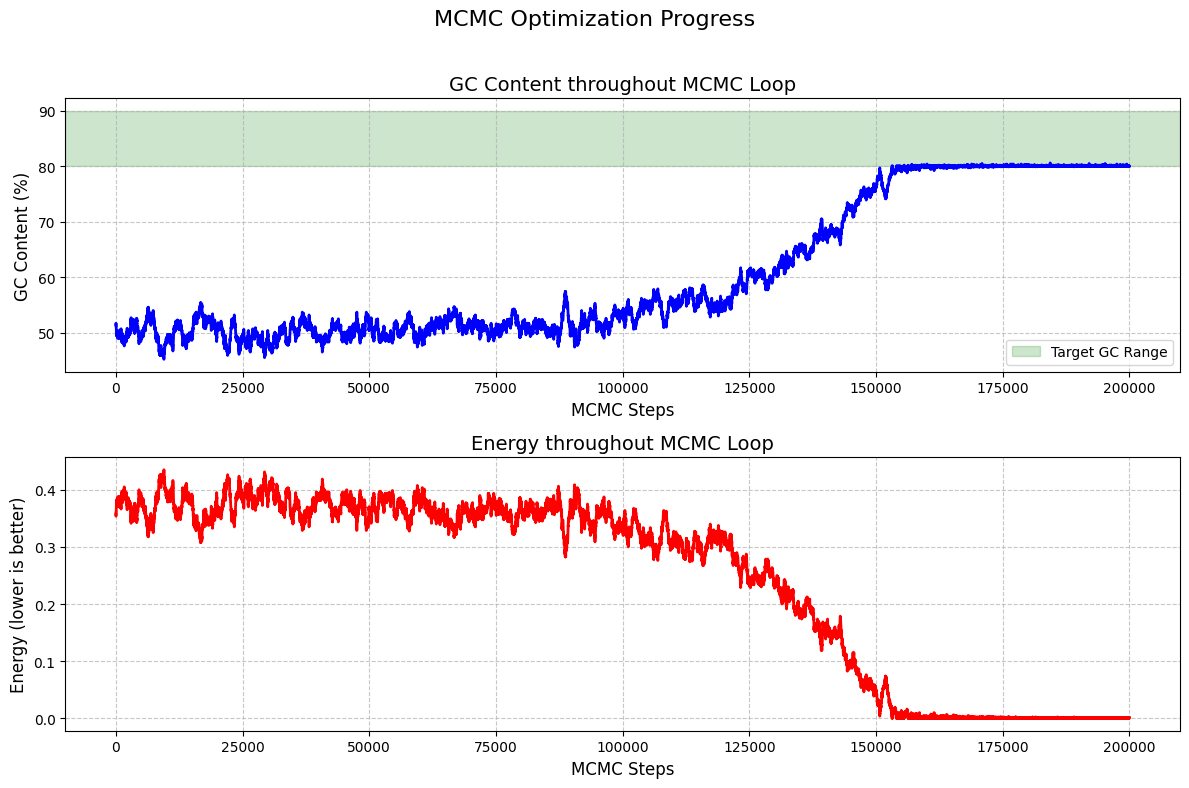

In [8]:
# Energy evolution plot
energy_history = [entry["energy_scores"][0] for entry in program.history]  # First batch element's energy
steps_history = [entry["time_step"] for entry in program.history]
gc_content_history = [analyze_gc_content(entry["constructs"][0].batch_sequences[0].sequence) for entry in program.history]

# Plot the evolution of GC content
plt.figure(figsize=(12, 8))

# GC content evolution
plt.subplot(2, 1, 1)
plt.plot(steps_history, gc_content_history, 'b-', linewidth=2)
plt.axhspan(MIN_GC, MAX_GC, color='g', alpha=0.2, label='Target GC Range')
plt.xlabel('MCMC Steps', fontsize=12)
plt.ylabel('GC Content (%)', fontsize=12)
plt.title('GC Content throughout MCMC Loop', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tick_params(labelsize=10)

# Energy evolution
plt.subplot(2, 1, 2)
plt.plot(steps_history, energy_history, 'r-', linewidth=2)
plt.xlabel('MCMC Steps', fontsize=12)
plt.ylabel('Energy (lower is better)', fontsize=12)
plt.title('Energy throughout MCMC Loop', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tick_params(labelsize=10)

# Add a main title for the entire figure
plt.suptitle('MCMC Optimization Progress', fontsize=16, y=0.98)

# Save the figure
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for suptitle
plt.show()